In [1]:
# 'parameters'
E_M = 1.0
E_I = 1.0
E_0 = 1e-8
h = 1e-3
m_Ju = 1.0
n_Ju = 0.5
m_Js = 1.0
n_Js = 0.5

out_dir = "."           # e.g. /.../case/out (passed by the script)
out_prefix = "run_tag"  # becomes your PDF filename prefix
work_dir = "."          # where .case lives
case_path = ""          # full path to .case (script sets; fallback below)

In [2]:
from paraview.simple import *
from paraview import servermanager
from vtk.util.numpy_support import vtk_to_numpy
import numpy as np
from vtkmodules.vtkCommonDataModel import vtkMultiBlockDataSet, vtkTable
from pathlib import Path
import pickle
import os

In [3]:
# If case_path isn't provided, try to discover the newest *.case in work_dir
if not case_path:
    candidates = sorted(Path(work_dir).glob("*.case"), key=lambda p: p.stat().st_mtime)
    case_path = str(candidates[-1]) if candidates else ""

print("case_path:", case_path)

case_path: Cohesive_zone_model_bottom.case


In [4]:
#directory_IN = "/home/alexsta1993/Documents/STATHAS_VIENNA_POSTDOC/Applications_Examples/EdelweisModels/Cohesive_Zone_models/3D/Three_Body_Cubit/Linear_Visco_Elastic_Interface_examples/Parametric_model/Three_body_mesh/angle/10/epsilon/10+8/n_10/"
#directory_IN = "/home/alexsta1993/Documents/STATHAS_VIENNA_POSTDOC/Applications_Examples/EdelweisModels/Cohesive_Zone_models/3D/Three_Body_Cubit/Simple_Layer_Tests/"

# --------- config: adjust selectors if your names differ ---------
TOP_SELECTOR = "/Root/topbody"         # from your trace
IF_SELECTOR  = "/Root/interfacebody"   # change to whatever your interface block is called

TOP_POINT_ID = 120
IF_CELL_ID   = 55

In [5]:
# --------- tiny helpers ----------
def extract_with_selector(src, selector):
    ext = ExtractBlock(Input=src)
    ext.Selectors = [selector]
    UpdatePipeline(proxy=ext)
    return ext

def first_table_from_proxy(pxy):
    fetched = servermanager.Fetch(pxy)
    if isinstance(fetched, vtkTable):
        return fetched
    if isinstance(fetched, vtkMultiBlockDataSet):
        # walk shallowly, grab the first vtkTable you find
        for i in range(fetched.GetNumberOfBlocks()):
            blk = fetched.GetBlock(i)
            if isinstance(blk, vtkTable):
                return blk
            if isinstance(blk, vtkMultiBlockDataSet):
                for j in range(blk.GetNumberOfBlocks()):
                    sub = blk.GetBlock(j)
                    if isinstance(sub, vtkTable):
                        return sub
    raise RuntimeError("No vtkTable found inside PlotSelectionOverTime output.")

def table_to_numpy_dict(tbl):
    out = {}
    for i in range(tbl.GetNumberOfColumns()):
        out[tbl.GetColumnName(i)] = vtk_to_numpy(tbl.GetColumn(i))
    return out

# fuzzy column matching: ignores case/spaces; tolerates "( block=1)"
def _norm(s): return "".join(s.lower().split())
def pick_col(columns, *tokens):
    want = [_norm(t) for t in tokens]
    for name in columns:
        n = _norm(name).replace("(block=", "(block=").replace(")(block=", ") (block=")  # mild cleanup
        if all(w in n for w in want):
            return name
    return None

# --------- open data ----------
top_src       = OpenDataFile("./Cohesive_zone_model_top.case")
interface_src = OpenDataFile("./Cohesive_zone_model_interface.case")
UpdatePipeline(proxy=top_src)
UpdatePipeline(proxy=interface_src)


In [6]:
# --------- extract by selector (exactly as in your trace) ----------
top_blk = extract_with_selector(top_src, TOP_SELECTOR)
if_blk  = extract_with_selector(interface_src, IF_SELECTOR)

In [7]:
# --------- build ID selections ----------
sel_top_pt = IDSelectionSource()
sel_top_pt.FieldType = "POINT"   # PV 5.11 uses singular enums
sel_top_pt.IDs = [0, TOP_POINT_ID]

sel_if_ce = IDSelectionSource()
sel_if_ce.FieldType = "CELL"
sel_if_ce.IDs = [0, IF_CELL_ID]

In [8]:
# --------- PlotSelectionOverTime for both ----------
plot_top = PlotSelectionOverTime(Input=top_blk, Selection=sel_top_pt)
UpdatePipeline(proxy=plot_top)

plot_if = PlotSelectionOverTime(Input=if_blk, Selection=sel_if_ce)
UpdatePipeline(proxy=plot_if)

In [9]:
# --------- fetch the tables (GUI shows these series exist) ----------
top_vtktable = first_table_from_proxy(plot_top)
if_vtktable  = first_table_from_proxy(plot_if)

top_tbl = table_to_numpy_dict(top_vtktable)
if_tbl  = table_to_numpy_dict(if_vtktable)

In [10]:
# --------- resolve the exact column names robustly ----------
# Time
time_name = pick_col(top_tbl.keys(), "time") or "Time"

# From your trace: 'displacement_top (Magnitude) ( block=1)' and 'reaction_top (Magnitude) ( block=1)'
disp_name  = pick_col(top_tbl.keys(), "displacement_top", "0")
react_name = pick_col(top_tbl.keys(), "reaction_top",     "0")

# Interface: 'force_interface (Magnitude) ( block=1)', 'surface_stress_interface (Magnitude) ( block=1)'
force_name  = pick_col(if_tbl.keys(), "force_interface",           "magnitude")
stress_name = pick_col(if_tbl.keys(), "surface_stress_interface",  "magnitude")


In [11]:
# Safety checks with helpful error if anything is missing
missing = [(lbl, nm) for lbl, nm in [
    ("time", time_name),
    ("displacement_top", disp_name),
    ("reaction_top", react_name),
    ("force_interface", force_name),
    ("surface_stress_interface", stress_name),
] if nm is None]
if missing:
    print("Available TOP columns:\n  " + "\n  ".join(sorted(top_tbl.keys())))
    print("\nAvailable IF columns:\n  " + "\n  ".join(sorted(if_tbl.keys())))
    raise KeyError("Could not resolve columns: " + ", ".join(f"{lbl}" for lbl, _ in missing))

In [12]:
# --------- final NumPy arrays you asked for ----------
time = np.asarray(top_tbl[time_name], dtype=float)

displacement_top_mag = np.asarray(top_tbl[disp_name], dtype=float)
reaction_top_mag     = np.abs(np.asarray(top_tbl[react_name], dtype=float))

force_interface_mag         = np.asarray(if_tbl[force_name], dtype=float)
surface_stress_interface_mag = np.asarray(if_tbl[stress_name], dtype=float)


In [13]:
# quick summary
print("OK:")
print(" time:", time.shape, "->", time_name)
print(" top: displacement_mag:", displacement_top_mag.shape, "->", disp_name)
print(" top: reaction_mag:",     reaction_top_mag.shape,     "->", react_name)
print(" if : force_mag:",        force_interface_mag.shape,  "->", force_name)
print(" if : surface_stress_mag:", surface_stress_interface_mag.shape, "->", stress_name)

OK:
 time: (6,) -> Time
 top: displacement_mag: (6,) -> min(displacement_top (0))
 top: reaction_mag: (6,) -> min(reaction_top (0))
 if : force_mag: (6,) -> min(force_interface (Magnitude))
 if : surface_stress_mag: (6,) -> min(surface_stress_interface (Magnitude))


In [14]:
#-----------Calculate effective nondimansional parameters
u_max = h #np.max(displacement_top_mag)

# --- Define effective moduli ---
E_u_eff = (2.0 / E_0 - 1.0 / E_M - 1.0 / E_I) ** (-1) + n_Ju
E_s_eff = (E_M + E_I - 2.0 * E_0) - n_Js

In [15]:
# --- Keys for the dictionary ---
#a = u_max * E_u_eff / E_s_eff
#b = m_Ju / m_Js
a_key = f"{u_max * E_s_eff / E_u_eff:.8g}"
b_key = f"{m_Ju / m_Js:.8f}"

# --- Data container ---
data_entry = [time, displacement_top_mag, force_interface_mag, surface_stress_interface_mag]

In [16]:
# --- File path ---
out = Path(out_dir) / "parametric_curves_creep.pkl"

# --- Load or create dictionary ---
if out.exists():
    with out.open("rb") as f:
        parametric_curves_creep = pickle.load(f)
else:
    parametric_curves_creep = {}

# --- Append / update entry keyed by (a, b) ---
parametric_curves_creep[(a_key, b_key)] = data_entry

# --- Save back ---
with out.open("wb") as f:
    pickle.dump(parametric_curves_creep, f)

# --- Optional: show last entry ---
print("Stored entry for (a, b) =", (a_key, b_key))
print("→", data_entry)

Stored entry for (a, b) = ('99999.999', '1.00000000')
→ [array([0.00000000e+00, 9.99999994e-09, 2.50000996e-03, 5.00001013e-03,
       7.50001008e-03, 1.00000100e-02]), array([0.        , 0.00251145, 0.00313514, 0.00375882, 0.0043825 ,
       0.00500617]), array([0.00000000e+00, 2.22054314e-06, 2.22065728e-06, 2.22074686e-06,
       2.22081690e-06, 2.22087169e-06]), array([0.00000000e+00, 6.27091822e-07, 6.83367546e-07, 6.83382098e-07,
       6.83391590e-07, 6.83400572e-07])]


In [17]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker

In [18]:
# --- Global rcParams ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.labelsize": 22,       # Axis labels fontsize
    "xtick.labelsize": 18,      # X tick labels fontsize
    "ytick.labelsize": 18,      # Y tick labels fontsize
    "xtick.direction": "in",    # X ticks inward
    "ytick.direction": "in",    # Y ticks inward
    "xtick.top": True,          # Show ticks on top
    "ytick.right": True,        # Show ticks on right
    #"axes.grid": True,          # Enable grid
    #"grid.linestyle": "--",     # Grid style
    #"grid.alpha": 0.4           # Grid transparency
})

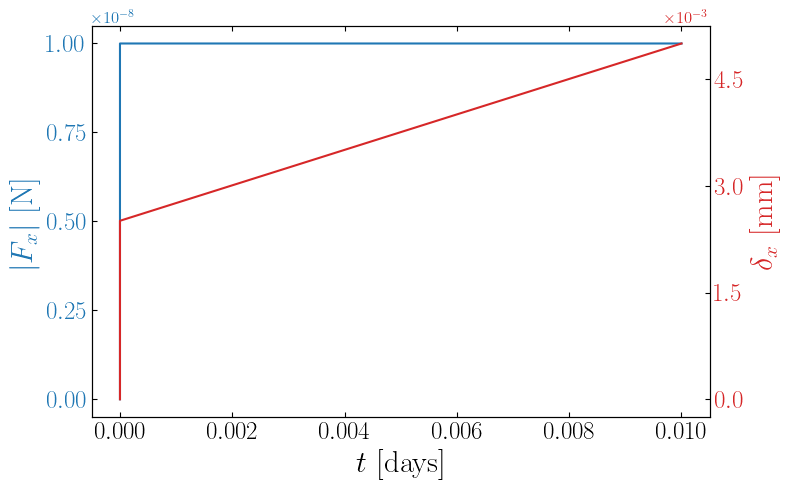

In [19]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Left y-axis: reaction
color = "tab:blue"
ax1.set_xlabel(r"$t$ [days]")
ax1.set_ylabel(r"$\big|F_x\big|$ [N]", color=color)
ax1.plot(time, reaction_top_mag, color=color, label=r"$\\||F_x\\||$ [N]")
ax1.tick_params(axis="y", labelcolor=color, direction="in")
ax1.tick_params(axis="x", direction="in")

# Force scientific notation with factor shown at top
ax1.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax1.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax1.yaxis.get_offset_text().set_position((0, 1.02))  # x=0, y just above top ticks
ax1.yaxis.get_offset_text().set_fontsize(12)

# Limit number of ticks
ax1.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

# Right y-axis: displacement
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel(r"$\delta_x$ [mm]", color=color)
ax2.plot(time, displacement_top_mag, color=color, label=r"$u_x [mm]$")
ax2.tick_params(axis="y", labelcolor=color, direction="in")

ax2.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

# Force scientific notation (right y-axis)
ax2.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax2.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax2.yaxis.get_offset_text().set_position((1, 1.02))  # x=1 so it doesn’t overlap
ax2.yaxis.get_offset_text().set_fontsize(12)

# Grid, legends, and tight layout
#ax1.grid(True, which="both", linestyle="--", alpha=0.5)
ax1.grid(False)
fig.tight_layout()

#plt.show()
out = Path(out_dir) / "Reaction_displacement"
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / f"{out_prefix}.pdf", bbox_inches="tight")

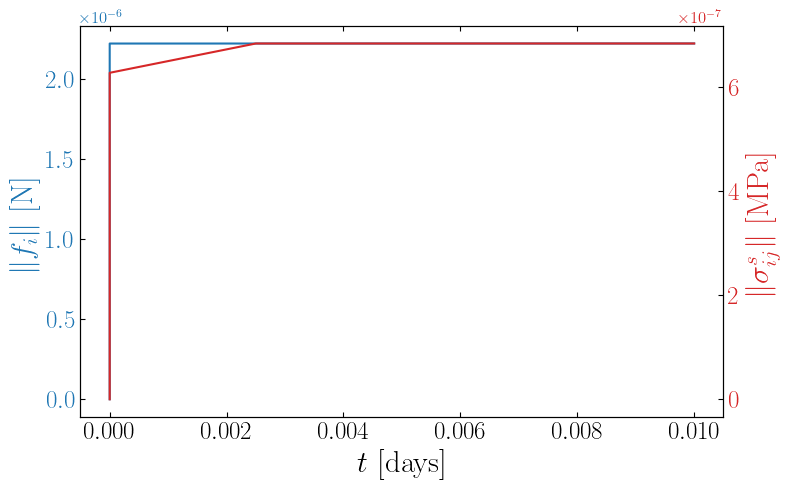

In [20]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Left y-axis: reaction
color = "tab:blue"
ax1.set_xlabel(r"$t$ [days]")
ax1.set_ylabel(r"$\|f_i\|$ [N]", color=color)
ax1.plot(time, force_interface_mag, color=color, label=r"$\|f_i\|$ [N]")
ax1.tick_params(axis="y", labelcolor=color, direction="in")
ax1.tick_params(axis="x", direction="in")

# Force scientific notation with factor shown at top
ax1.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax1.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax1.yaxis.get_offset_text().set_position((0, 1.02))  # x=0, y just above top ticks
ax1.yaxis.get_offset_text().set_fontsize(12)

# Limit number of ticks
ax1.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

# Right y-axis: displacement
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel(r"$\|\sigma^s_{ij}\|$ [MPa]", color=color)
ax2.plot(time, surface_stress_interface_mag, color=color, label=r"$t [days]$")
ax2.tick_params(axis="y", labelcolor=color, direction="in")

ax2.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

# Force scientific notation (right y-axis)
ax2.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax2.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax2.yaxis.get_offset_text().set_position((1, 1.02))  # x=1 so it doesn’t overlap
ax2.yaxis.get_offset_text().set_fontsize(12)

# Grid, legends, and tight layout
#ax1.grid(True, which="both", linestyle="--", alpha=0.5)
ax1.grid(False)
fig.tight_layout()

#plt.show()

#plt.show()
out = Path(out_dir) / "force_surface_stress"
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / f"{out_prefix}.pdf", bbox_inches="tight")